Connected to venv (Python 3.9.21)

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic



# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

#@pf.register_dataframe_method
def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')

        alerts_table = soupy.find('div', id='tab-pane-overview-alerts').find('table', class_='table-striped')

        if alerts_table:
            for row in alerts_table.find_all('tr'):
                cells = row.find_all('td')
                if cells:  # Check if the row has cells
                    link = cells[0].find('a')
                    if link:
                        variable_name = link.text.strip()
                        message = cells[0].text.replace(variable_name, "").replace(" has constant value '?'", "").replace(" is highly overall correlated with ", "").replace(" is highly imbalanced (", "").replace(" has ", "").replace(" missing values", "").replace(" is uniformly distributed", "").strip()
                        badge = cells[1].find('span', class_='badge')
                        alert_type = badge.text.strip() if badge else None
                        other_fields_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                        other_fields = other_fields_span['data-bs-title'] if other_fields_span else None

                        print(f"Variable: {variable_name}") 
                        
                        print(f"Message: {message}")
                        print(f"Alert Type: {alert_type}")
                        print(f"Other Fields: {other_fields}")
                        print("-" * 20)

                        if alert_type == "High correlation":
                            correlation_dict[variable_name] = other_fields

        else:
            print("Alerts table not found.")

    except Exception as e: # Handle potential exceptions
        print(f"An error occurred: {e}")

    finally:
        driver.quit()  # Ensure driver quits in all cases

    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict


if alert_type:
    print(f"Alert Type: '{alert_type}'")  # Add quotes to see exact text
    
    # Case-insensitive comparison
    if alert_type.lower() == "high correlation":
        correlation_dict[variable_name] = other_fields

correlation_dict = webscrape_report()

print (correlation_dict)

NameError: name 'alert_type' is not defined

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic



# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')

        alerts_table = soupy.find('div', id='tab-pane-overview-alerts').find('table', class_='table-striped')

        if alerts_table:
            for row in alerts_table.find_all('tr'):
                cells = row.find_all('td')
                if cells:  # Check if the row has cells
                    link = cells[0].find('a')
                    if link:
                        variable_name = link.text.strip()
                        message = cells[0].text.replace(variable_name, "").replace.replace(" is highly overall correlated with ", "").replace(" is highly imbalanced (", "").strip()
                        badge = cells[1].find('span', class_='badge')
                        alert_type = badge.text.strip() if badge else None
                        other_fields_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                        other_fields = other_fields_span['data-bs-title'] if other_fields_span else None

                        print(f"Variable: {variable_name}") 
                        
                        print(f"Message: {message}")
                        print(f"Alert Type: {alert_type}")
                        print(f"Other Fields: {other_fields}")
                        print("-" * 20)

                        if alert_type == "High correlation":
                            correlation_dict[variable_name] = other_fields

        else:
            print("Alerts table not found.")

    except Exception as e: # Handle potential exceptions
        print(f"An error occurred: {e}")

    finally:
        driver.quit()  # Ensure driver quits in all cases

    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict


    
    
    
    
    
    
    if alert_type:
        print(f"Alert Type: '{alert_type}'")  # Add quotes to see exact text
        
        # Case-insensitive comparison
        if alert_type.lower() == "high correlation":
            correlation_dict[variable_name] = other_fields

    correlation_dict = webscrape_report()

print (correlation_dict)

NameError: name 'correlation_dict' is not defined

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic



# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')

        alerts_table = soupy.find('div', id='tab-pane-overview-alerts').find('table', class_='table-striped')

        if alerts_table:
            for row in alerts_table.find_all('tr'):
                cells = row.find_all('td')
                if cells:  # Check if the row has cells
                    link = cells[0].find('a')
                    if link:
                        variable_name = link.text.strip()
                        message = cells[0].text.replace(variable_name, "").replace.replace(" is highly overall correlated with ", "").replace(" is highly imbalanced (", "").strip()
                        badge = cells[1].find('span', class_='badge')
                        alert_type = badge.text.strip() if badge else None
                        other_fields_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                        other_fields = other_fields_span['data-bs-title'] if other_fields_span else None

                        print(f"Variable: {variable_name}") 
                        
                        print(f"Message: {message}")
                        print(f"Alert Type: {alert_type}")
                        print(f"Other Fields: {other_fields}")
                        print("-" * 20)

                        if alert_type == "High correlation":
                            correlation_dict[variable_name] = other_fields

        else:
            print("Alerts table not found.")

    except Exception as e: # Handle potential exceptions
        print(f"An error occurred: {e}")

    finally:
        driver.quit()  # Ensure driver quits in all cases

    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating'),
            ('age_group', 'rating'),
            ('activity', 'rating'),
            ('personality', 'rating'),
            ('User_cuisine', 'rating'),
            
            # Demographic Effects
            ('age_group', 'budget'),
            ('age_group', 'User_cuisine'),
            ('age_group', 'drink_level'),
            ('age_group', 'dress_preference'),
            ('activity', 'budget'),
            ('activity', 'transport'),
            ('marital_status', 'hijos'),
            ('marital_status', 'budget'),
            ('marital_status', 'user_ambience'),
            
            # Restaurant Selection Effects
            ('transport', 'accessibility'),
            ('transport', 'area'),
            ('budget', 'price'),
            
            # Personal Attribute Effects
            ('weight', 'food_rating'),
            ('personality', 'food_rating'),
            ('height', 'food_rating'),
            ('color', 'food_rating'),
            ('hijos', 'food_rating'),
            
            # Service Rating Influences
            ('color', 'service_rating'),
            ('personality', 'service_rating'),
            
            # Transport and Accessibility Chain
            ('transport', 'smoker'),
            ('transport', 'dress_preference'),
            ('transport', 'weight')
        ]
        

    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
        'rating': ['rating'],
        'direct_effects': ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine'],
        'demographics': [ 'marital_status'],
        'preferences': ['budget', 'drink_level', 'dress_preference'],
        'transport': ['transport', 'accessibility', 'area'],
        'personal': ['weight', 'height', 'color', 'hijos', 'smoker'],
        'restaurant': ['Rcuisine_y', 'price', 'user_ambience']
    }
    

    colors = {
        'rating': '#ff6666',        # Red
        'direct_effects': '#ffa366', # Orange
        'demographics': '#66b3ff',   # Blue
        'preferences': '#66ff66',    # Green
        'transport': '#ffff66',      # Yellow
        'personal': '#ff66ff',       # Pink
        'restaurant': '#a366ff'      # Purple
    }
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    node_colors = []
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_colors.append(colors.get(category, '#gray'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in colors.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html
2026-01-20 12:47:11,396 - INFO - ====== WebDriver manager ======
2026-01-20 12:47:11,783 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 12:47:11,945 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 12:47:12,046 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 12:47:12,557 - INFO - WebDriver version 143.0.7499.192 selected
2026-01-20 12:47:12,569 - INFO - Modern chrome version https://storage.googleapis.com/chrome-for-testing-public/143.0.7499.192/mac-arm64/chromedriver-mac-arm64.zip
2026-01-20 12:47:12,570 - INFO - About to download new driver from https://storage.googleapis.com/chrome-for-testing-public/143.0.7499.192/mac-arm64/chromedriver-mac-arm64.zip
2026-01-20 12:47:12,726 - INFO - Driver downloading response is 200
2026-01-20 12:47:14,545 - INFO - Get LATEST chromedriver version for go

In [ ]:
dic = webscrape_report()

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html
2026-01-20 12:48:14,558 - INFO - ====== WebDriver manager ======
2026-01-20 12:48:14,980 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 12:48:15,115 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 12:48:15,227 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
An error occurred: 'NoneType' object has no attribute 'find'

High Correlation Summary:


In [ ]:
print (dic)

{}


Connected to venv (Python 3.9.21)

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic



# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()

    finally:
        driver.quit()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

        
        
        
        
        
        
        
        
        
        
        
        
        
        

        alerts_table = soupy.find('div', id='tab-pane-overview-alerts').find('table', class_='table-striped')

        if alerts_table:
            for row in alerts_table.find_all('tr'):
                cells = row.find_all('td')
                if cells:  # Check if the row has cells
                    link = cells[0].find('a')
                    if link:
                        variable_name = link.text.strip()
                        message = cells[0].text.replace(variable_name, "").replace.replace(" is highly overall correlated with ", "").replace(" is highly imbalanced (", "").strip()
                        badge = cells[1].find('span', class_='badge')
                        alert_type = badge.text.strip() if badge else None
                        other_fields_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                        other_fields = other_fields_span['data-bs-title'] if other_fields_span else None

                        print(f"Variable: {variable_name}") 
                        
                        print(f"Message: {message}")
                        print(f"Alert Type: {alert_type}")
                        print(f"Other Fields: {other_fields}")
                        print("-" * 20)

                        if alert_type == "High correlation":
                            correlation_dict[variable_name] = other_fields

        else:
            print("Alerts table not found.")

    except Exception as e: # Handle potential exceptions
        print(f"An error occurred: {e}")

    finally:
        driver.quit()  # Ensure driver quits in all cases

    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict


    
    
dic = webscrape_report()

print (dic)

IndentationError: unexpected indent (<ipython-input-1-39ca52cac722>, line 118)

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic



# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        with open(file_path, 'r', encoding='utf-8') as file:
            html = file.read()
        
        soupy = BeautifulSoup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells and len(cells) > 0:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

In [ ]:
d = webscrape_report()

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html
2026-01-20 14:25:01,221 - INFO - ====== WebDriver manager ======
2026-01-20 14:25:01,556 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:25:01,781 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:25:01,894 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Error: File not found at /Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html

High Correlation Summary:


In [ ]:
pwd

'/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module'

In [ ]:
os.chdir('/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/')

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic



# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        with open(file_path, 'r', encoding='utf-8') as file:
            html = file.read()
        
        soupy = BeautifulSoup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells and len(cells) > 0:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

        
        


d = webscrape_report()

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-20 14:28:39,283 - INFO - ====== WebDriver manager ======
2026-01-20 14:28:39,602 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:28:39,723 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:28:39,840 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
An error occurred: name 'BeautifulSoup' is not defined

High Correlation Summary:


Traceback (most recent call last):
  File "<ipython-input-6-8e6db5c58f6f>", line 60, in webscrape_report
    soupy = BeautifulSoup(html, 'html.parser')
NameError: name 'BeautifulSoup' is not defined


In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic



# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        with open(file_path, 'r', encoding='utf-8') as file:
            html = file.read()
        
        soupy = soup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells and len(cells) > 0:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

        
        


d = webscrape_report()

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-20 14:30:06,368 - INFO - ====== WebDriver manager ======
2026-01-20 14:30:06,725 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:30:06,832 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:30:06,930 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
-------

In [ ]:
print (d)

{'Business_hours': 'area, state, zip', 'accessibility': 'area, city, placeID, restaurant_specialty, smoking_area, state, zip', 'activity': 'age_group, marital_status, p.longitude, weight', 'age': 'age_group, ambience, birth_year, drink_level, hijos', 'age_group': 'activity, age, birth_year, color, p.longitude, patrons_restaurant_distance', 'alcohol': 'restaurant_specialty, url, zip', 'ambiance': 'restaurant_specialty, state', 'ambience': 'age, birth_year, color, height, interest, transport, weight', 'area': 'Business_hours, accessibility, smoking_area, state', 'birth_year': 'age, age_group, ambience, drink_level, hijos', 'budget': 'color, height, hijos, transport', 'city': 'accessibility, country, latitude, location_cluster, longitude, other_services, p.latitude, p.longitude, placeID, state, zip', 'color': 'age_group, ambience, budget, drink_level, food_rating, hijos, interest, personality, rating, service_rating, transport', 'country': 'city, restaurant_specialty, state, zip', 'drink_

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating')]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
        'rating': ['rating'],
        'direct_effects': ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine'],
        'demographics': [ 'marital_status'],
        'preferences': ['budget', 'drink_level', 'dress_preference'],
        'transport': ['transport', 'accessibility', 'area'],
        'personal': ['weight', 'height', 'color', 'hijos', 'smoker'],
        'restaurant': ['Rcuisine_y', 'price', 'user_ambience']
    }
    

    colors = {
        'rating': '#ff6666',        # Red
        'direct_effects': '#ffa366', # Orange
        'demographics': '#66b3ff',   # Blue
        'preferences': '#66ff66',    # Green
        'transport': '#ffff66',      # Yellow
        'personal': '#ff66ff',       # Pink
        'restaurant': '#a366ff'      # Purple
    }
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    node_colors = []
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_colors.append(colors.get(category, '#gray'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in colors.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-20 14:32:39,865 - INFO - ====== WebDriver manager ======
2026-01-20 14:32:40,204 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:32:40,315 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:32:40,419 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
-------

In [ ]:
g = causal_digraph(correlation_dict= webscrape_report()

)

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-20 14:33:37,526 - INFO - ====== WebDriver manager ======
2026-01-20 14:33:37,885 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:33:37,997 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:33:38,118 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
-------

In [ ]:
print (g)

CausalGraphicalModel(food_rating, rating, service_rating)


In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating')]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm, nodes, edges
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
        'rating': ['rating'],
        'direct_effects': ['food_rating', 'service_rating', 'age_group', 'activity', 'personality', 'User_cuisine'],
        'demographics': [ 'marital_status'],
        'preferences': ['budget', 'drink_level', 'dress_preference'],
        'transport': ['transport', 'accessibility', 'area'],
        'personal': ['weight', 'height', 'color', 'hijos', 'smoker'],
        'restaurant': ['Rcuisine_y', 'price', 'user_ambience']
    }
    

    colors = {
        'rating': '#ff6666',        # Red
        'direct_effects': '#ffa366', # Orange
        'demographics': '#66b3ff',   # Blue
        'preferences': '#66ff66',    # Green
        'transport': '#ffff66',      # Yellow
        'personal': '#ff66ff',       # Pink
        'restaurant': '#a366ff'      # Purple
    }
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    node_colors = []
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_colors.append(colors.get(category, '#gray'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in colors.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-20 14:37:00,412 - INFO - ====== WebDriver manager ======
2026-01-20 14:37:00,797 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:37:00,915 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 14:37:01,013 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
-------

Connected to venv (Python 3.9.21)

In [ ]:
print (d)

NameError: name 'd' is not defined

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic

In [ ]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        with open(file_path, 'r', encoding='utf-8') as file:
            html = file.read()
        
        soupy = soup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells and len(cells) > 0:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

        
        


d = webscrape_report()
print (d)

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html
2026-01-20 15:36:00,010 - INFO - ====== WebDriver manager ======
2026-01-20 15:36:00,407 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 15:36:00,532 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 15:36:00,649 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Error: File not found at /Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html

High Correlation Summary:
{}


In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic

In [ ]:
print (d)

{}


In [ ]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        with open(file_path, 'r', encoding='utf-8') as file:
            html = file.read()
        
        soupy = soup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells and len(cells) > 0:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

        
        


d = webscrape_report()
print (d)

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html
2026-01-20 15:37:15,600 - INFO - ====== WebDriver manager ======
2026-01-20 15:37:15,961 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 15:37:16,094 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 15:37:16,195 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Error: File not found at /Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html

High Correlation Summary:
{}


In [ ]:
pwd

'/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module'

In [ ]:
os.chdir('/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv')

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating')]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm, nodes, edges
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = 
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    node_colors = []
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_colors.append(colors.get(category, '#gray'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in colors.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

SyntaxError: invalid syntax (<ipython-input-9-f0ae1ab66538>, line 111)

In [ ]:
d = webscrape_report()

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-20 15:39:51,934 - INFO - ====== WebDriver manager ======
2026-01-20 15:39:52,254 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 15:39:52,385 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 15:39:52,492 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
-------

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating')]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = [
    'outcome': ['rating'],
    
    'primary_factors': ['food_rating', 'service_rating'],
    
    'user_demographics': ['age', 'age_group', 'marital_status', 'hijos'],
    
    'user_physical': ['weight', 'height', 'color'],
    
    'user_preferences': ['activity', 'ambience', 'interest', 'personality', 'drink_level', 'budget'],
    
    'user_location': ['location_cluster', 'patrons_restaurant_distance'],
    
    'restaurant_location': ['area', 'zip'],
    
    'restaurant_attributes': ['restaurant_specialty', 'franchise', 'price', 'Business_hours', 'url', 'dress_code'],
    
    'restaurant_features': ['accessibility', 'parking_lot', 'smoking_area', 'alcohol', 'ambiance', 'other_services']
    ]
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    node_colors = ['outcome': '#FF6B6B',
    'primary_factors': '#4ECDC4',
    'user_demographics': '#95E1D3',
    'user_physical': '#F7DC6F',
    'user_preferences': '#FFE66D',
    'user_location': '#FF8B94',
    'restaurant_location': '#A8E6CF',
    'restaurant_attributes': '#C7CEEA',
    'restaurant_features': '#B4A7D6',
    'other': '#CCCCCC'
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_colors.append(colors.get(category, '#gray'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in colors.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

SyntaxError: invalid syntax (<ipython-input-11-09a42cd00dfe>, line 112)

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating')]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = [
    'outcome': ['rating'],
    
    'primary_factors': ['food_rating', 'service_rating'],
    
    'user_demographics': ['age', 'age_group', 'marital_status', 'hijos'],
    
    'user_physical': ['weight', 'height', 'color'],
    
    'user_preferences': ['activity', 'ambience', 'interest', 'personality', 'drink_level', 'budget'],
    
    'user_location': ['location_cluster', 'patrons_restaurant_distance'],
    
    'restaurant_location': ['area', 'zip'],
    
    'restaurant_attributes': ['restaurant_specialty', 'franchise', 'price', 'Business_hours', 'url', 'dress_code'],
    
    'restaurant_features': ['accessibility', 'parking_lot', 'smoking_area', 'alcohol', 'ambiance', 'other_services']
    ]
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    node_colors = ['outcome': '#FF6B6B',
    'primary_factors': '#4ECDC4',
    'user_demographics': '#95E1D3',
    'user_physical': '#F7DC6F',
    'user_preferences': '#FFE66D',
    'user_location': '#FF8B94',
    'restaurant_location': '#A8E6CF',
    'restaurant_attributes': '#C7CEEA',
    'restaurant_features': '#B4A7D6',
    'other': '#CCCCCC']
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_colors.append(colors.get(category, '#gray'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in colors.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

SyntaxError: invalid syntax (<ipython-input-12-25ccf3096e9c>, line 112)

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating')]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
    'outcome': ['rating'],
    
    'primary_factors': ['food_rating', 'service_rating'],
    
    'user_demographics': ['age', 'age_group', 'marital_status', 'hijos'],
    
    'user_physical': ['weight', 'height', 'color'],
    
    'user_preferences': ['activity', 'ambience', 'interest', 'personality', 'drink_level', 'budget'],
    
    'user_location': ['location_cluster', 'patrons_restaurant_distance'],
    
    'restaurant_location': ['area', 'zip'],
    
    'restaurant_attributes': ['restaurant_specialty', 'franchise', 'price', 'Business_hours', 'url', 'dress_code'],
    
    'restaurant_features': ['accessibility', 'parking_lot', 'smoking_area', 'alcohol', 'ambiance', 'other_services']
    }
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    node_colors = ['outcome': '#FF6B6B',
    'primary_factors': '#4ECDC4',
    'user_demographics': '#95E1D3',
    'user_physical': '#F7DC6F',
    'user_preferences': '#FFE66D',
    'user_location': '#FF8B94',
    'restaurant_location': '#A8E6CF',
    'restaurant_attributes': '#C7CEEA',
    'restaurant_features': '#B4A7D6',
    'other': '#CCCCCC']
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_colors.append(colors.get(category, '#gray'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in colors.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

SyntaxError: invalid syntax (<ipython-input-13-88a223aab3d6>, line 138)

In [ ]:
d = webscrape_report()

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-20 16:35:16,695 - INFO - ====== WebDriver manager ======
2026-01-20 16:35:17,140 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 16:35:17,277 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 16:35:17,399 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
-------

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating')]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
    'outcome': ['rating'],
    
    'primary_factors': ['food_rating', 'service_rating'],
    
    'user_demographics': ['age', 'age_group', 'marital_status', 'hijos'],
    
    'user_physical': ['weight', 'height', 'color'],
    
    'user_preferences': ['activity', 'ambience', 'interest', 'personality', 'drink_level', 'budget'],
    
    'user_location': ['location_cluster', 'patrons_restaurant_distance'],
    
    'restaurant_location': ['area', 'zip'],
    
    'restaurant_attributes': ['restaurant_specialty', 'franchise', 'price', 'Business_hours', 'url', 'dress_code'],
    
    'restaurant_features': ['accessibility', 'parking_lot', 'smoking_area', 'alcohol', 'ambiance', 'other_services']
    ]
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    node_colors = {'outcome': '#FF6B6B',
    'primary_factors': '#4ECDC4',
    'user_demographics': '#95E1D3',
    'user_physical': '#F7DC6F',
    'user_preferences': '#FFE66D',
    'user_location': '#FF8B94',
    'restaurant_location': '#A8E6CF',
    'restaurant_attributes': '#C7CEEA',
    'restaurant_features': '#B4A7D6',
    'other': '#CCCCCC'}
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_colors.append(colors.get(category, '#gray'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in colors.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

SyntaxError: closing parenthesis ']' does not match opening parenthesis '{' on line 111 (<ipython-input-15-22c64e368a9e>, line 129)

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating')]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
    'outcome': ['rating'],
    
    'primary_factors': ['food_rating', 'service_rating'],
    
    'user_demographics': ['age', 'age_group', 'marital_status', 'hijos'],
    
    'user_physical': ['weight', 'height', 'color'],
    
    'user_preferences': ['activity', 'ambience', 'interest', 'personality', 'drink_level', 'budget'],
    
    'user_location': ['location_cluster', 'patrons_restaurant_distance'],
    
    'restaurant_location': ['area', 'zip'],
    
    'restaurant_attributes': ['restaurant_specialty', 'franchise', 'price', 'Business_hours', 'url', 'dress_code'],
    
    'restaurant_features': ['accessibility', 'parking_lot', 'smoking_area', 'alcohol', 'ambiance', 'other_services']
    ]
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    node_colors = {'outcome': '#FF6B6B',
    'primary_factors': '#4ECDC4',
    'user_demographics': '#95E1D3',
    'user_physical': '#F7DC6F',
    'user_preferences': '#FFE66D',
    'user_location': '#FF8B94',
    'restaurant_location': '#A8E6CF',
    'restaurant_attributes': '#C7CEEA',
    'restaurant_features': '#B4A7D6',
    'other': '#CCCCCC'}
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_colors.append(colors.get(category, '#gray'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in colors.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

SyntaxError: closing parenthesis ']' does not match opening parenthesis '{' on line 111 (<ipython-input-16-22c64e368a9e>, line 129)

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ('food_rating', 'rating'),
            ('service_rating', 'rating')]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
    'outcome': ['rating'],
    
    'primary_factors': ['food_rating', 'service_rating'],
    
    'user_demographics': ['age', 'age_group', 'marital_status', 'hijos'],
    
    'user_physical': ['weight', 'height', 'color'],
    
    'user_preferences': ['activity', 'ambience', 'interest', 'personality', 'drink_level', 'budget'],
    
    'user_location': ['location_cluster', 'patrons_restaurant_distance'],
    
    'restaurant_location': ['area', 'zip'],
    
    'restaurant_attributes': ['restaurant_specialty', 'franchise', 'price', 'Business_hours', 'url', 'dress_code'],
    
    'restaurant_features': ['accessibility', 'parking_lot', 'smoking_area', 'alcohol', 'ambiance', 'other_services']
    }
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    color_map = {'outcome': '#FF6B6B',
    'primary_factors': '#4ECDC4',
    'user_demographics': '#95E1D3',
    'user_physical': '#F7DC6F',
    'user_preferences': '#FFE66D',
    'user_location': '#FF8B94',
    'restaurant_location': '#A8E6CF',
    'restaurant_attributes': '#C7CEEA',
    'restaurant_features': '#B4A7D6',
    'other': '#CCCCCC'}
    
    # Build list of colors for each node
    node_color_list = []
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_color_list.append(color_map.get(category, '#CCCCCC'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_color_list,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in color_map.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-20 16:38:01,247 - INFO - ====== WebDriver manager ======
2026-01-20 16:38:01,698 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 16:38:01,834 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 16:38:01,937 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
-------

In [ ]:
print (d)

{'Business_hours': 'area, state, zip', 'accessibility': 'area, city, placeID, restaurant_specialty, smoking_area, state, zip', 'activity': 'age_group, marital_status, p.longitude, weight', 'age': 'age_group, ambience, birth_year, drink_level, hijos', 'age_group': 'activity, age, birth_year, color, p.longitude, patrons_restaurant_distance', 'alcohol': 'restaurant_specialty, url, zip', 'ambiance': 'restaurant_specialty, state', 'ambience': 'age, birth_year, color, height, interest, transport, weight', 'area': 'Business_hours, accessibility, smoking_area, state', 'birth_year': 'age, age_group, ambience, drink_level, hijos', 'budget': 'color, height, hijos, transport', 'city': 'accessibility, country, latitude, location_cluster, longitude, other_services, p.latitude, p.longitude, placeID, state, zip', 'color': 'age_group, ambience, budget, drink_level, food_rating, hijos, interest, personality, rating, service_rating, transport', 'country': 'city, restaurant_specialty, state, zip', 'drink_

In [ ]:
d = webscrape_report()
print (d)

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-20 16:50:43,042 - INFO - ====== WebDriver manager ======
2026-01-20 16:50:43,428 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 16:50:43,543 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-20 16:50:43,660 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/143.0.7499.192/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
-------

No kernel connected

No kernel connected

No kernel connected

Connected to venv (Python 3.9.21)

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic

In [ ]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        with open(file_path, 'r', encoding='utf-8') as file:
            html = file.read()
        
        soupy = soup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells and len(cells) > 0:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

        
        


d = webscrape_report()
print (d)



correlation_edges =[
    
 ("color", "rating"),          
("food_rating", "rating"),     
("height", "rating"),          
("hijos", "rating"),           
("interest", "rating"),        
("personality", "rating"),    
("service_rating", "rating"),  
 
 # Business_hours (3 edges)
 ("area", "Business_hours")
 
 # Food rating:
 ("height", "food_rating"),
 ("hijos", "food_rating"),
 
 # Service rating
 ("color", "service_rating"),
 
 # height (9 edges)
    ("height", "ambience"),
    ("height", "budget"),
    ("height", "drink_level"),

    ("height", "personality"),
    ("height", "transport"),
    ("height", "weight"),
    
    # Inetrest
    ("interest", "ambience"),
    
    ("interest", "height"),

    # Color edges
    ("age_group", "color"),
    ("ambience", "color"),
    ("budget", "color"),
    ("drink_level", "color"),
    
    ("hijos", "color"),
    ("interest", "color"),
    ("personality", "color"),
    
    #Activity
    ("marital_status", "activity"),  
    ("weight", "activity"),
    ("age_group", "activity"),
    
    # Interest
    ("height", "interest"),
    
    
    #age_group
    ("age_group", "patrons_restaurant_distance"),
        
    # accessibility (7 edges)
    ("accessibility", "area"),
    ("accessibility", "restaurant_specialty"),
    ("accessibility", "smoking_area"),
    
    # Children 
    ("hijos", "budget"),
    ("hijos", "transport"),
    
    # Personalities 
    ("personality", "color"),
    ("personality", "food_rating"),
    ("height", "personality"),  
    ("weight", "personality")
    
    # alcohol (3 edges)
    ("alcohol", "restaurant_specialty"),
    ("alcohol", "url"),
    
    # ambiance (2 edges)
    ("ambiance", "restaurant_specialty"),

    # ambience (7 edges)
    ("ambience", "color"),
    ("ambience", "height"),
    ("ambience", "interest"),
    ("ambience", "transport"),
    ("ambience", "weight"),
    
    # area (4 edges)
    ("area", "accessibility"),
    ("area", "smoking_area"),
    ("area", "Business_hours"),
    
    
    # budget (4 edges)
    ("budget", "color"),
    ("budget", "height"),
    ("budget", "transport"),
    
    
    # drink_level (6 edges)
    ("drink_level", "height"),
    ("drink_level", "transport"),
    ("drink_level", "weight"),
    

    # franchise (3 edges)
    ("franchise", "location_cluster"),
    ("franchise", "restaurant_specialty"),
    ("franchise", "zip"),
    
     # price (3 edges)
     ("restaurant_specialty", "price"),  
    ("url", "price"),                  
    ("zip", "price"),            
    
    # location_cluster (9 edges)
    ("location_cluster", "franchise"),
    ("location_cluster", "restaurant_specialty"),
    ("zip", "location_cluster"),
    
    # marital_status (2 edges)
    ("marital_status", "activity"),
    ("marital_status", "transport"),
    
    # other_services (3 edges)
    ("other_services", "restaurant_specialty"),

    # parking_lot (2 edges)
    ("restaurant_specialty", "parking_lot", ),
    ("zip" ,  "parking_lot", ),
    
    # patrons_restaurant_distance (2 edges)
    ("patrons_restaurant_distance", "age_group"),
  
    # personality (5 edges)
    ("personality", "color"),
    ("personality", "food_rating"),
    ("personality", "height"),
    ("personality", "weight"),
    
    # restaurant_specialty (11 edges)
    ("restaurant_specialty", "accessibility"),
    ("restaurant_specialty", "alcohol"),
    ("restaurant_specialty", "ambiance"),
    ("restaurant_specialty", "location_cluster"),
    ("restaurant_specialty", "other_services"),
    ("restaurant_specialty", "parking_lot"),
    ("restaurant_specialty", "price"),
    ("restaurant_specialty", "smoking_area"),
    
    # transport (8 edges)
    ("transport", "ambience"),
    ("transport", "color"),
    ("transport", "drink_level"),
    ("marital_status", "transport", ),
     ("budget", "transport"),
    
    # weight (7 edges)
    ("weight", "activity"),
    ("weight", "ambience"),
    ("weight", "drink_level"),
    ("weight", "food_rating"),
    ("weight", "personality"),
    ("weight", "transport")]

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html
2026-01-22 15:16:59,088 - INFO - ====== WebDriver manager ======


<>:107: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<>:165: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<>:107: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<>:165: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?


2026-01-22 15:16:59,632 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:16:59,781 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:16:59,874 - INFO - There is no [mac64] chromedriver "144.0.7559.96" for browser google-chrome "144.0.7559" in cache
2026-01-22 15:16:59,876 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:17:00,041 - INFO - WebDriver version 144.0.7559.96 selected
2026-01-22 15:17:00,053 - INFO - Modern chrome version https://storage.googleapis.com/chrome-for-testing-public/144.0.7559.96/mac-arm64/chromedriver-mac-arm64.zip
2026-01-22 15:17:00,055 - INFO - About to download new driver from https://storage.googleapis.com/chrome-for-testing-public/144.0.7559.96/mac-arm64/chromedriver-mac-arm64.zip
2026-01-22 15:17:00,116 - INFO - Driver downloading response is 200
2026-01-22 15:17:00,540 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:17:00,752 - INFO - Driver has been saved in 

<ipython-input-2-12c5b16aaf0d>:107: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ("area", "Business_hours")
<ipython-input-2-12c5b16aaf0d>:165: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ("weight", "personality")
<ipython-input-2-12c5b16aaf0d>:107: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ("area", "Business_hours")
<ipython-input-2-12c5b16aaf0d>:165: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ("weight", "personality")
<ipython-input-2-12c5b16aaf0d>:107: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ("area", "Business_hours")
<ipython-input-2-12c5b16aaf0d>:165: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ("weight", "personality")
<ipython-input-2-12c5b16aaf0d>:107: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  ("area", "Business_hours")
<ipython-input-2-12c5b1

TypeError: 'tuple' object is not callable

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = correlation_edges

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ("color", "rating"),          
            ("food_rating", "rating"),      
            ("height", "rating"),          
            ("hijos", "rating"),           
            ("interest", "rating"),        
            ("personality", "rating"),      
            ("service_rating", "rating"), ]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
        'outcome': ['rating'],
        'primary_factors': ['food_rating', 'service_rating'],
        'user_demographics': ['age', 'age_group', 'marital_status', 'hijos'],
        'user_physical': ['weight', 'height', 'color'],
        'user_preferences': ['activity', 'ambience', 'interest', 'personality', 'drink_level', 'budget', 'transport'],
        'user_location': ['location_cluster', 'patrons_restaurant_distance'],
        'restaurant_location': ['area', 'zip'],
        'restaurant_attributes': ['restaurant_specialty', 'franchise', 'price', 'Business_hours', 'url', 'dress_code'],
        'restaurant_features': ['accessibility', 'parking_lot', 'smoking_area', 'alcohol', 'ambiance', 'other_services']
    }
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    color_map = {'outcome': '#FF6B6B',
    'primary_factors': '#4ECDC4',
    'user_demographics': '#95E1D3',
    'user_physical': '#F7DC6F',
    'user_preferences': '#FFE66D',
    'user_location': '#FF8B94',
    'restaurant_location': '#A8E6CF',
    'restaurant_attributes': '#C7CEEA',
    'restaurant_features': '#B4A7D6',
    'other': '#CCCCCC'}
    
    # Build list of colors for each node
    node_color_list = []
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_color_list.append(color_map.get(category, '#CCCCCC'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_color_list,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in color_map.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html
2026-01-22 15:23:26,875 - INFO - ====== WebDriver manager ======
2026-01-22 15:23:27,306 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:23:27,372 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:23:27,421 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/144.0.7559.96/chromedriver-mac-arm64/chromedriver] found in cache
Error: File not found at /Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html

High Correlation Summary:
2026-01-22 15:23:29,385 - ERROR - Error creating causal graph: free variable 'correlation_edges' referenced before assignment in enclosing scope
2026-01-22 15:23:29,389 - WARNING - Returning fallback causal graph with only base edges
CausalGraphicalModel(color, food_rating, height, hijos, interest, personality, 

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic

In [ ]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        with open(file_path, 'r', encoding='utf-8') as file:
            html = file.read()
        
        soupy = soup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells and len(cells) > 0:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

        
        


d = webscrape_report()
print (d)



correlation_edges =[
    
  
 
 # Business_hours (3 edges)
 ("area", "Business_hours"),
 
 # Food rating:
 ("height", "food_rating"),
 ("hijos", "food_rating"),
 
 # Service rating
 ("color", "service_rating"),
 
 # height (9 edges)
    ("height", "ambience"),
    ("height", "budget"),
    ("height", "drink_level"),

    ("height", "personality"),
    ("height", "transport"),
    ("height", "weight"),
    
    # Inetrest
    ("interest", "ambience"),
    
    ("interest", "height"),

    # Color edges
    ("age_group", "color"),
    ("ambience", "color"),
    ("budget", "color"),
    ("drink_level", "color"),
    
    ("hijos", "color"),
    ("interest", "color"),
    ("personality", "color"),
    
    #Activity
    ("marital_status", "activity"),  
    ("weight", "activity"),
    ("age_group", "activity"),
    
    # Interest
    ("height", "interest"),
    
    
    #age_group
    ("age_group", "patrons_restaurant_distance"),
        
    # accessibility (7 edges)
    ("accessibility", "area"),
    ("accessibility", "restaurant_specialty"),
    ("accessibility", "smoking_area"),
    
    # Children 
    ("hijos", "budget"),
    ("hijos", "transport"),
    
    # Personalities 
    ("personality", "color"),
    ("personality", "food_rating"),
    ("height", "personality"),  
    ("weight", "personality"),
    
    # alcohol (3 edges)
    ("alcohol", "restaurant_specialty"),
    ("alcohol", "url"),
    
    # ambiance (2 edges)
    ("ambiance", "restaurant_specialty"),

    # ambience (7 edges)
    ("ambience", "color"),
    ("ambience", "height"),
    ("ambience", "interest"),
    ("ambience", "transport"),
    ("ambience", "weight"),
    
    # area (4 edges)
    ("area", "accessibility"),
    ("area", "smoking_area"),
    ("area", "Business_hours"),
    
    
    # budget (4 edges)
    ("budget", "color"),
    ("budget", "height"),
    ("budget", "transport"),
    
    
    # drink_level (6 edges)
    ("drink_level", "height"),
    ("drink_level", "transport"),
    ("drink_level", "weight"),
    

    # franchise (3 edges)
    ("franchise", "location_cluster"),
    ("franchise", "restaurant_specialty"),
    ("franchise", "zip"),
    
     # price (3 edges)
     ("restaurant_specialty", "price"),  
    ("url", "price"),                  
    ("zip", "price"),            
    
    # location_cluster (9 edges)
    ("location_cluster", "franchise"),
    ("location_cluster", "restaurant_specialty"),
    ("zip", "location_cluster"),
    
    # marital_status (2 edges)
    ("marital_status", "activity"),
    ("marital_status", "transport"),
    
    # other_services (3 edges)
    ("other_services", "restaurant_specialty"),

    # parking_lot (2 edges)
    ("restaurant_specialty", "parking_lot", ),
    ("zip" ,  "parking_lot", ),
    
    # patrons_restaurant_distance (2 edges)
    ("patrons_restaurant_distance", "age_group"),
  
    # personality (5 edges)
    ("personality", "color"),
    ("personality", "food_rating"),
    ("personality", "height"),
    ("personality", "weight"),
    
    # restaurant_specialty (11 edges)
    ("restaurant_specialty", "accessibility"),
    ("restaurant_specialty", "alcohol"),
    ("restaurant_specialty", "ambiance"),
    ("restaurant_specialty", "location_cluster"),
    ("restaurant_specialty", "other_services"),
    ("restaurant_specialty", "parking_lot"),
    ("restaurant_specialty", "price"),
    ("restaurant_specialty", "smoking_area"),
    
    # transport (8 edges)
    ("transport", "ambience"),
    ("transport", "color"),
    ("transport", "drink_level"),
    ("marital_status", "transport", ),
     ("budget", "transport"),
    
    # weight (7 edges)
    ("weight", "activity"),
    ("weight", "ambience"),
    ("weight", "drink_level"),
    ("weight", "food_rating"),
    ("weight", "personality"),
    ("weight", "transport")]

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html
2026-01-22 15:24:27,039 - INFO - ====== WebDriver manager ======
2026-01-22 15:24:27,609 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:24:27,667 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:24:27,716 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/144.0.7559.96/chromedriver-mac-arm64/chromedriver] found in cache
Error: File not found at /Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module/Reports/eda_report.html

High Correlation Summary:
{}


In [ ]:
pwd

'/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/causal_analysis_module'

In [ ]:
os.chdir('/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv')

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic

In [ ]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        with open(file_path, 'r', encoding='utf-8') as file:
            html = file.read()
        
        soupy = soup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells and len(cells) > 0:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

        
        


d = webscrape_report()
print (d)



correlation_edges =[
    
  
 
 # Business_hours (3 edges)
 ("area", "Business_hours"),
 
 # Food rating:
 ("height", "food_rating"),
 ("hijos", "food_rating"),
 
 # Service rating
 ("color", "service_rating"),
 
 # height (9 edges)
    ("height", "ambience"),
    ("height", "budget"),
    ("height", "drink_level"),

    ("height", "personality"),
    ("height", "transport"),
    ("height", "weight"),
    
    # Inetrest
    ("interest", "ambience"),
    
    ("interest", "height"),

    # Color edges
    ("age_group", "color"),
    ("ambience", "color"),
    ("budget", "color"),
    ("drink_level", "color"),
    
    ("hijos", "color"),
    ("interest", "color"),
    ("personality", "color"),
    
    #Activity
    ("marital_status", "activity"),  
    ("weight", "activity"),
    ("age_group", "activity"),
    
    # Interest
    ("height", "interest"),
    
    
    #age_group
    ("age_group", "patrons_restaurant_distance"),
        
    # accessibility (7 edges)
    ("accessibility", "area"),
    ("accessibility", "restaurant_specialty"),
    ("accessibility", "smoking_area"),
    
    # Children 
    ("hijos", "budget"),
    ("hijos", "transport"),
    
    # Personalities 
    ("personality", "color"),
    ("personality", "food_rating"),
    ("height", "personality"),  
    ("weight", "personality"),
    
    # alcohol (3 edges)
    ("alcohol", "restaurant_specialty"),
    ("alcohol", "url"),
    
    # ambiance (2 edges)
    ("ambiance", "restaurant_specialty"),

    # ambience (7 edges)
    ("ambience", "color"),
    ("ambience", "height"),
    ("ambience", "interest"),
    ("ambience", "transport"),
    ("ambience", "weight"),
    
    # area (4 edges)
    ("area", "accessibility"),
    ("area", "smoking_area"),
    ("area", "Business_hours"),
    
    
    # budget (4 edges)
    ("budget", "color"),
    ("budget", "height"),
    ("budget", "transport"),
    
    
    # drink_level (6 edges)
    ("drink_level", "height"),
    ("drink_level", "transport"),
    ("drink_level", "weight"),
    

    # franchise (3 edges)
    ("franchise", "location_cluster"),
    ("franchise", "restaurant_specialty"),
    ("franchise", "zip"),
    
     # price (3 edges)
     ("restaurant_specialty", "price"),  
    ("url", "price"),                  
    ("zip", "price"),            
    
    # location_cluster (9 edges)
    ("location_cluster", "franchise"),
    ("location_cluster", "restaurant_specialty"),
    ("zip", "location_cluster"),
    
    # marital_status (2 edges)
    ("marital_status", "activity"),
    ("marital_status", "transport"),
    
    # other_services (3 edges)
    ("other_services", "restaurant_specialty"),

    # parking_lot (2 edges)
    ("restaurant_specialty", "parking_lot", ),
    ("zip" ,  "parking_lot", ),
    
    # patrons_restaurant_distance (2 edges)
    ("patrons_restaurant_distance", "age_group"),
  
    # personality (5 edges)
    ("personality", "color"),
    ("personality", "food_rating"),
    ("personality", "height"),
    ("personality", "weight"),
    
    # restaurant_specialty (11 edges)
    ("restaurant_specialty", "accessibility"),
    ("restaurant_specialty", "alcohol"),
    ("restaurant_specialty", "ambiance"),
    ("restaurant_specialty", "location_cluster"),
    ("restaurant_specialty", "other_services"),
    ("restaurant_specialty", "parking_lot"),
    ("restaurant_specialty", "price"),
    ("restaurant_specialty", "smoking_area"),
    
    # transport (8 edges)
    ("transport", "ambience"),
    ("transport", "color"),
    ("transport", "drink_level"),
    ("marital_status", "transport", ),
     ("budget", "transport"),
    
    # weight (7 edges)
    ("weight", "activity"),
    ("weight", "ambience"),
    ("weight", "drink_level"),
    ("weight", "food_rating"),
    ("weight", "personality"),
    ("weight", "transport")]

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-22 15:27:20,835 - INFO - ====== WebDriver manager ======
2026-01-22 15:27:21,235 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:27:21,294 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:27:21,341 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/144.0.7559.96/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
--------

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_dict: Dict[str, str]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_dict: A dictionary of correlations, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships_dict(correlation_dict: Dict[str, str]) -> List[Tuple[str, str]]:
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = correlation_edges

        if not correlation_dict:
            print("Warning: Empty correlation dictionary provided")  # Keep print for visibility
            return additional_edges

        for source, targets in correlation_dict.items():
            if not targets:
                print(f"Warning: No targets found for source '{source}'")  # Keep print for visibility
                continue

            try:
                target_list = [t.strip() for t in targets.split(',') if t.strip()]

                for target in target_list:
                    if target:
                        additional_edges.append((str(source), str(target)))

            except Exception as e:
                print(f"Error processing source '{source}': {str(e)}")  # Keep print for visibility
                continue

        print(f"Successfully created {len(additional_edges)} edges from correlation dictionary")  # Keep print for visibility
        return additional_edges

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ("color", "rating"),          
            ("food_rating", "rating"),      
            ("height", "rating"),          
            ("hijos", "rating"),           
            ("interest", "rating"),        
            ("personality", "rating"),      
            ("service_rating", "rating"), ]
    try:
        correlation_edges = parse_relationships_dict(correlation_dict)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = list(G.nodes())
        edges = list(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    


g = causal_digraph(correlation_dict= webscrape_report()

)
print (g)




#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
        'outcome': ['rating'],
        'primary_factors': ['food_rating', 'service_rating'],
        'user_demographics': ['age', 'age_group', 'marital_status', 'hijos'],
        'user_physical': ['weight', 'height', 'color'],
        'user_preferences': ['activity', 'ambience', 'interest', 'personality', 'drink_level', 'budget', 'transport'],
        'user_location': ['location_cluster', 'patrons_restaurant_distance'],
        'restaurant_location': ['area', 'zip'],
        'restaurant_attributes': ['restaurant_specialty', 'franchise', 'price', 'Business_hours', 'url', 'dress_code'],
        'restaurant_features': ['accessibility', 'parking_lot', 'smoking_area', 'alcohol', 'ambiance', 'other_services']
    }
    
    # Set up the plot
    plt.figure(figsize=figsize)
    
    # Create layout
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # Draw nodes by category
    color_map = {'outcome': '#FF6B6B',
    'primary_factors': '#4ECDC4',
    'user_demographics': '#95E1D3',
    'user_physical': '#F7DC6F',
    'user_preferences': '#FFE66D',
    'user_location': '#FF8B94',
    'restaurant_location': '#A8E6CF',
    'restaurant_attributes': '#C7CEEA',
    'restaurant_features': '#B4A7D6',
    'other': '#CCCCCC'}
    
    # Build list of colors for each node
    node_color_list = []
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_color_list.append(color_map.get(category, '#CCCCCC'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_color_list,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in color_map.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return plt

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-22 15:27:59,763 - INFO - ====== WebDriver manager ======
2026-01-22 15:28:00,209 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:28:00,270 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:28:00,320 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/144.0.7559.96/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
--------

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-22 15:30:13,537 - INFO - ====== WebDriver manager ======
2026-01-22 15:30:13,973 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:30:14,031 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-22 15:30:14,074 - INFO - Driver [/Users/ellandalla/.wdm/drivers/chromedriver/mac64/144.0.7559.96/chromedriver-mac-arm64/chromedriver] found in cache
Variable: Business_hours
Correlated Fields: area, state, zip
--------------------------------------------------
Variable: accessibility
Correlated Fields: area, city, placeID, restaurant_specialty, smoking_area, state, zip
--------------------------------------------------
Variable: activity
Correlated Fields: age_group, marital_status, p.longitude, weight
--------------------------------------------------
Variable: age
Correlated Fields: age_group, ambience, birth_year, drink_level, hijos
--------

<ipython-input-10-45e76e53026c>:203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


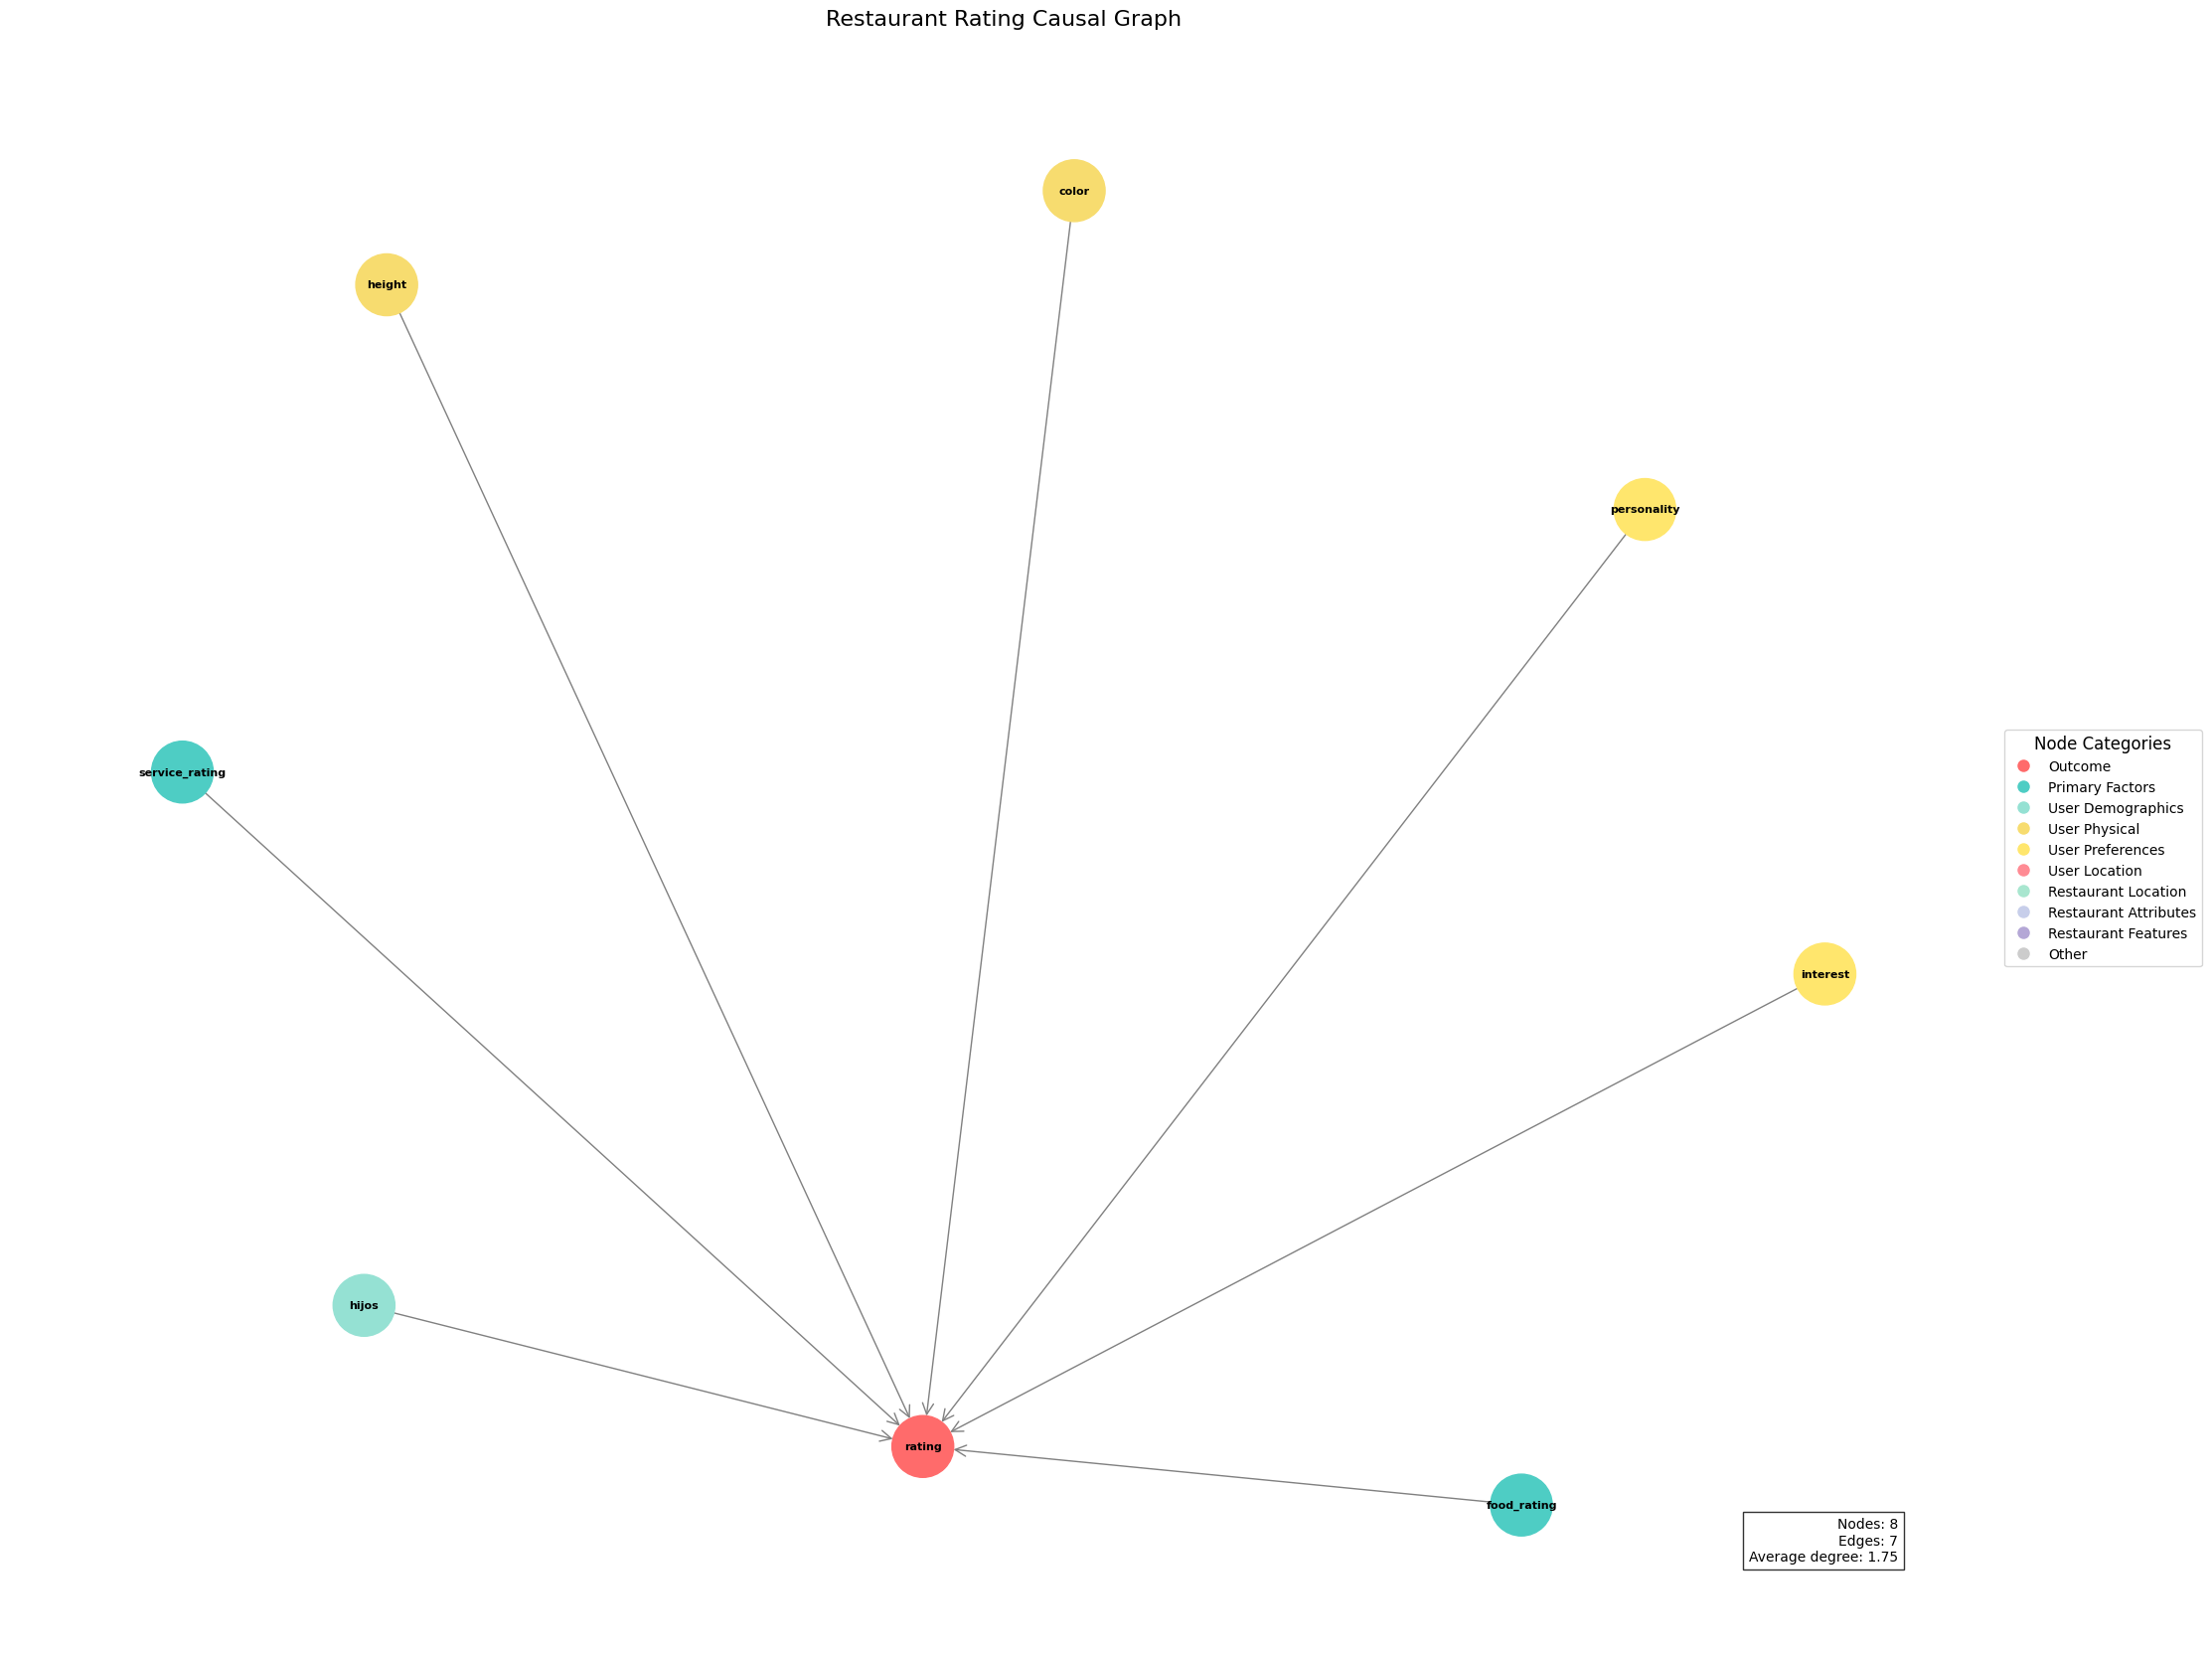

In [ ]:
G = create_causal_visualization(
   cgm= causal_digraph(correlation_dict=webscrape_report()))

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic

In [ ]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

def webscrape_report():
    """
    Web scrapes a Ydata EDA HTML report to extract information about data quality alerts,
    specifically focusing on high correlations.

    Returns:
        A dictionary where keys are variable names with high correlation alerts,
        and values are the corresponding "other fields" information.
    """

    file_path = os.path.abspath("Reports/eda_report.html")
    file_url = "file://" + file_path
    print(f"File URL: {file_url}")  # Print for debugging

    executable_path = ChromeDriverManager().install()
    service = Service(executable_path)
    options = Options()

    # Options to try to avoid detection 
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option('useAutomationExtension', False)

    driver = webdriver.Chrome(service=service, options=options)
    correlation_dict = {}

    try:
        driver.get(file_url)
        html = driver.page_source
        soupy = soup(html, 'html.parser')
        with open(file_path, 'r', encoding='utf-8') as file:
            html = file.read()
        
        soupy = soup(html, 'html.parser')
        alerts_table = soupy.find('div', id='tab-pane-overview-alerts')
        
        if alerts_table:
            table = alerts_table.find('table', class_='table-striped')
            
            if table:
                for row in table.find_all('tr'):
                    cells = row.find_all('td')
                    if cells and len(cells) > 0:
                        # Extract variable name from first <code> tag
                        first_code = cells[0].find('code')
                        if first_code:
                            variable_name = first_code.text.strip()
                            
                            # Extract tooltip data
                            tooltip_span = cells[0].find('span', attrs={'data-bs-toggle': 'tooltip'})
                            if tooltip_span and 'data-bs-title' in tooltip_span.attrs:
                                tooltip_data = tooltip_span['data-bs-title']
                                
                                # Check if it's a correlation alert
                                if 'highly overall correlated' in cells[0].text:
                                    correlation_dict[variable_name] = tooltip_data
                                    
                                    print(f"Variable: {variable_name}")
                                    print(f"Correlated Fields: {tooltip_data}")
                                    print("-" * 50)
            else:
                print("Table not found within alerts div.")
        else:
            print("Alerts div not found.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()
    
    # Print summary of high correlations after scraping
    print("\nHigh Correlation Summary:")
    for variable_name, fields in correlation_dict.items():
        print(f"Variable: {variable_name}, Other Fields: {fields}")

    return correlation_dict

        
        


d = webscrape_report()
print (d)



correlation_edges =[
    
 # Business_hours (3 edges)
 ("area", "Business_hours"),
 
 # Food rating:
 ("height", "food_rating"),
 ("hijos", "food_rating"),
 
 # Service rating
 ("color", "service_rating"),
 
 # height (9 edges)
    ("height", "ambience"),
    ("height", "budget"),
    ("height", "drink_level"),

    ("height", "personality"),
    ("height", "transport"),
    ("height", "weight"),
    
    # Inetrest
    ("interest", "ambience"),
    
    ("interest", "height"),

    # Color edges
    ("age_group", "color"),
    ("ambience", "color"),
    ("budget", "color"),
    ("drink_level", "color"),
    
    ("hijos", "color"),
    ("interest", "color"),
    ("personality", "color"),
    
    #Activity
    ("marital_status", "activity"),  
    ("weight", "activity"),
    ("age_group", "activity"),
    
    # Interest
    ("height", "interest"),
    
    
    #age_group
    ("age_group", "patrons_restaurant_distance"),
        
    # accessibility (7 edges)
    ("accessibility", "area"),
    ("accessibility", "restaurant_specialty"),
    ("accessibility", "smoking_area"),
    
    # Children 
    ("hijos", "budget"),
    ("hijos", "transport"),
    
    # Personalities 
    ("personality", "color"),
    ("personality", "food_rating"),
    ("height", "personality"),  
    ("weight", "personality"),
    
    # alcohol (3 edges)
    ("alcohol", "restaurant_specialty"),
    ("alcohol", "url"),
    
    # ambiance (2 edges)
    ("ambiance", "restaurant_specialty"),

    # ambience (7 edges)
    ("ambience", "color"),
    ("ambience", "height"),
    ("ambience", "interest"),
    ("ambience", "transport"),
    ("ambience", "weight"),
    
    # area (4 edges)
    ("area", "accessibility"),
    ("area", "smoking_area"),
    ("area", "Business_hours"),
    
    
    # budget (4 edges)
    ("budget", "color"),
    ("budget", "height"),
    ("budget", "transport"),
    
    
    # drink_level (6 edges)
    ("drink_level", "height"),
    ("drink_level", "transport"),
    ("drink_level", "weight"),
    

    # franchise (3 edges)
    ("franchise", "location_cluster"),
    ("franchise", "restaurant_specialty"),
    ("franchise", "zip"),
    
     # price (3 edges)
     ("restaurant_specialty", "price"),  
    ("url", "price"),                  
    ("zip", "price"),            
    
    # location_cluster (9 edges)
    ("location_cluster", "franchise"),
    ("location_cluster", "restaurant_specialty"),
    ("zip", "location_cluster"),
    
    # marital_status (2 edges)
    ("marital_status", "activity"),
    ("marital_status", "transport"),
    
    # other_services (3 edges)
    ("other_services", "restaurant_specialty"),

    # parking_lot (2 edges)
    ("restaurant_specialty", "parking_lot", ),
    ("zip" ,  "parking_lot", ),
    
    # patrons_restaurant_distance (2 edges)
    ("patrons_restaurant_distance", "age_group"),
  
    # personality (5 edges)
    ("personality", "color"),
    ("personality", "food_rating"),
    ("personality", "height"),
    ("personality", "weight"),
    
    # restaurant_specialty (11 edges)
    ("restaurant_specialty", "accessibility"),
    ("restaurant_specialty", "alcohol"),
    ("restaurant_specialty", "ambiance"),
    ("restaurant_specialty", "location_cluster"),
    ("restaurant_specialty", "other_services"),
    ("restaurant_specialty", "parking_lot"),
    ("restaurant_specialty", "price"),
    ("restaurant_specialty", "smoking_area"),
    
    # transport (8 edges)
    ("transport", "ambience"),
    ("transport", "color"),
    ("transport", "drink_level"),
    ("marital_status", "transport", ),
     ("budget", "transport"),
    
    # weight (7 edges)
    ("weight", "activity"),
    ("weight", "ambience"),
    ("weight", "drink_level"),
    ("weight", "food_rating"),
    ("weight", "personality"),
    ("weight", "transport")]

File URL: file:///Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv/Reports/eda_report.html
2026-01-23 12:56:08,392 - INFO - ====== WebDriver manager ======
2026-01-23 12:56:16,260 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-23 12:56:16,549 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-23 12:56:16,697 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-23 12:56:17,133 - INFO - WebDriver version 144.0.7559.96 selected
2026-01-23 12:56:17,144 - INFO - Modern chrome version https://storage.googleapis.com/chrome-for-testing-public/144.0.7559.96/mac-arm64/chromedriver-mac-arm64.zip
2026-01-23 12:56:17,146 - INFO - About to download new driver from https://storage.googleapis.com/chrome-for-testing-public/144.0.7559.96/mac-arm64/chromedriver-mac-arm64.zip
2026-01-23 12:56:17,346 - INFO - Driver downloading response is 200
2026-01-23 12:56:18,165 - INFO - Get LATEST chromedriver version for google-chrome
2026-01-23 12:

WebDriverException: Message: Service /Users/ellandalla/.wdm/drivers/chromedriver/mac64/144.0.7559.96/chromedriver-mac-arm64/chromedriver unexpectedly exited. Status code was: -9


In [ ]:
pwd()

'/Users/ellandalla/Documents/GitHub/Causal_inference-Case_study/venv'

In [ ]:
import os
import os
from bs4 import BeautifulSoup as soup
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

#for causal_grapgh
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Set, Tuple
import logging, sys
import pandas_flavor as pf
from geopy.distance import geodesic

In [ ]:
correlation_edges =[
    
 # Business_hours (3 edges)
 ("area", "Business_hours"),
 
 # Food rating:
 ("height", "food_rating"),
 ("hijos", "food_rating"),
 
 # Service rating
 ("color", "service_rating"),
 
 # height (9 edges)
    ("height", "ambience"),
    ("height", "budget"),
    ("height", "drink_level"),

    ("height", "personality"),
    ("height", "transport"),
    ("height", "weight"),
    
    # Inetrest
    ("interest", "ambience"),
    
    ("interest", "height"),

    # Color edges
    ("age_group", "color"),
    ("ambience", "color"),
    ("budget", "color"),
    ("drink_level", "color"),
    
    ("hijos", "color"),
    ("interest", "color"),
    ("personality", "color"),
    
    #Activity
    ("marital_status", "activity"),  
    ("weight", "activity"),
    ("age_group", "activity"),
    
    # Interest
    ("height", "interest"),
    
    
    #age_group
    ("age_group", "patrons_restaurant_distance"),
        
    # accessibility (7 edges)
    ("accessibility", "area"),
    ("accessibility", "restaurant_specialty"),
    ("accessibility", "smoking_area"),
    
    # Children 
    ("hijos", "budget"),
    ("hijos", "transport"),
    
    # Personalities 
    ("personality", "color"),
    ("personality", "food_rating"),
    ("height", "personality"),  
    ("weight", "personality"),
    
    # alcohol (3 edges)
    ("alcohol", "restaurant_specialty"),
    ("alcohol", "url"),
    
    # ambiance (2 edges)
    ("ambiance", "restaurant_specialty"),

    # ambience (7 edges)
    ("ambience", "color"),
    ("ambience", "height"),
    ("ambience", "interest"),
    ("ambience", "transport"),
    ("ambience", "weight"),
    
    # area (4 edges)
    ("area", "accessibility"),
    ("area", "smoking_area"),
    ("area", "Business_hours"),
    
    
    # budget (4 edges)
    ("budget", "color"),
    ("budget", "height"),
    ("budget", "transport"),
    
    
    # drink_level (6 edges)
    ("drink_level", "height"),
    ("drink_level", "transport"),
    ("drink_level", "weight"),
    

    # franchise (3 edges)
    ("franchise", "location_cluster"),
    ("franchise", "restaurant_specialty"),
    ("franchise", "zip"),
    
     # price (3 edges)
     ("restaurant_specialty", "price"),  
    ("url", "price"),                  
    ("zip", "price"),            
    
    # location_cluster (9 edges)
    ("location_cluster", "franchise"),
    ("location_cluster", "restaurant_specialty"),
    ("zip", "location_cluster"),
    
    # marital_status (2 edges)
    ("marital_status", "activity"),
    ("marital_status", "transport"),
    
    # other_services (3 edges)
    ("other_services", "restaurant_specialty"),

    # parking_lot (2 edges)
    ("restaurant_specialty", "parking_lot", ),
    ("zip" ,  "parking_lot", ),
    
    # patrons_restaurant_distance (2 edges)
    ("patrons_restaurant_distance", "age_group"),
  
    # personality (5 edges)
    ("personality", "color"),
    ("personality", "food_rating"),
    ("personality", "height"),
    ("personality", "weight"),
    
    # restaurant_specialty (11 edges)
    ("restaurant_specialty", "accessibility"),
    ("restaurant_specialty", "alcohol"),
    ("restaurant_specialty", "ambiance"),
    ("restaurant_specialty", "location_cluster"),
    ("restaurant_specialty", "other_services"),
    ("restaurant_specialty", "parking_lot"),
    ("restaurant_specialty", "price"),
    ("restaurant_specialty", "smoking_area"),
    
    # transport (8 edges)
    ("transport", "ambience"),
    ("transport", "color"),
    ("transport", "drink_level"),
    ("marital_status", "transport", ),
     ("budget", "transport"),
    
    # weight (7 edges)
    ("weight", "activity"),
    ("weight", "ambience"),
    ("weight", "drink_level"),
    ("weight", "food_rating"),
    ("weight", "personality"),
    ("weight", "transport")]

In [ ]:
# Create a causal Grapgh
#@pf.register_dataframe_method
def causal_digraph(correlation_edges: List[Tuple[str, str]]) -> CausalGraphicalModel:
    """
    Creates a causal graph incorporating base causal relationships and correlations.

    Args:
        correlation_tuples: A list of tuples taken from correlation dictionary, where keys are source variables
                          and values are comma-separated target variables.

    Returns:
        A CausalGraphicalModel object representing the causal graph.  Returns a 
        basic graph with only base edges in case of an error.
    """


    def extract_nodes_from_edges(edges: List[Tuple[str, str]]) -> Set[str]:
        """Extract unique nodes from a list of edges."""
        nodes = set()
        for source, target in edges:
            nodes.add(source)
            nodes.add(target)
        return nodes

    def parse_relationships( correlation_tuples: List[Tuple[str, str]]):
        """Parse the relationships dictionary to create edges with error handling."""
        
        additional_edges = []

        if not correlation_tuples:
            print("Warning: Empty correlation tuples provided")     
            return additional_edges
        
        for item in correlation_tuples:
            try:
                # Validate tuple structure
                if not isinstance(item, tuple) or len(item) != 2:
                    print (f"Warning: Invalid tuple structure: {item}")
                    continue
                source, target = item
        # Validate and clean values
                source_str = str(source).strip()
                target_str = str(target).strip()
        
                if not source_str or not target_str:
                    print ( f"Warning: Empty source or target in tuple: {item}")
            additional_edges.append(((source_str, target_str)))
            
            except Exception as e:
                print(f"Error processing tuple '{item}': {str(e)}")
                continue
    
        print(f"Successfully created {len(additional_edges)} edges from correlation tuples")
        return additional_edges

        

    # Base causal relationships (unchanged)
    base_edges = [
        # Direct Effects on Rating
            ("color", "rating"),          
            ("food_rating", "rating"),      
            ("height", "rating"),          
            ("hijos", "rating"),           
            ("interest", "rating"),        
            ("personality", "rating"),      
            ("service_rating", "rating"), ]
    try:
        correlation_edges = parse_relationships(correlation_edges)

        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        logging.info(f"Added {len(base_edges)} base edges")

        if correlation_edges:
            G.add_edges_from(correlation_edges)
            logging.info(f"Added {len(correlation_edges)} correlation edges")

        nodes = List(G.nodes())
        edges = List(G.edges())

        logging.debug("Edge details:")
        for edge in edges:
            logging.debug(f"  {edge[0]} -> {edge[1]}")

        cgm = CausalGraphicalModel(nodes=nodes, edges=edges)

        logging.info(f"Created causal graph with {len(nodes)} nodes and {len(edges)} edges")
        return cgm

    except Exception as e:
        logging.error(f"Error creating causal graph: {str(e)}")
        # Fallback: Basic graph with only base edges
        G = nx.DiGraph()
        G.add_edges_from(base_edges)
        cgm = CausalGraphicalModel(nodes=list(G.nodes()), edges=list(G.edges()))
        logging.warning("Returning fallback causal graph with only base edges") # Log the warning
        return cgm
    









#@pf.register_dataframe_method
def create_causal_visualization(cgm: CausalGraphicalModel, 
                              figsize: tuple = (20, 16)) -> plt.Figure:
    """
    Create a visualization of the causal graph with node categories
    *Args:
            cgm: CausalGraphicalModel object
            figsize: Figure size tuple 
        Returns:
        matplotlib Figure object
            
             
    """
    # Get the NetworkX graph
    G = cgm.dag
    
    # Define node categories and their colors
    node_categories = {
        'outcome': ['rating'],
        'primary_factors': ['food_rating', 'service_rating'],
        'user_demographics': [ 'age_group', 'marital_status', 'hijos'],
        'user_attributes': ['weight', 'height'],
        'user_preferences': ['activity', 'ambience', 'interest', 'personality', 'drink_level', 'budget', 'transport'],
        'user_location': ['location_cluster', 'patrons_restaurant_distance'],
        'restaurant_location': ['area', 'zip'],
        'restaurant_attributes': ['restaurant_specialty', 'franchise', 'price', 'Business_hours', 'url', 'dress_code'],
        'restaurant_features': ['accessibility', 'parking_lot', 'smoking_area', 'alcohol', 'ambiance', 'other_services']
    }
    
    # Set up the plot
    fig = plt.figure(figsize=figsize)
    
    # Draw nodes by category
    color_map = {'outcome': '#FF6B6B',
    'primary_factors': '#4ECDC4',
    'user_demographics': '#95E1D3',
    'user_attributes': '#F7DC6F',
    'user_preferences': '#FFE66D',
    'user_location': '#FF8B94',
    'restaurant_location': '#A8E6CF',
    'restaurant_attributes': '#C7CEEA',
    'restaurant_features': '#B4A7D6',
    'other': '#CCCCCC'}
    
    # Create layout
    
    try:
        pos = nx.spring_layout(G, k=2, iterations=50, seed =42)
    except:
        pos = nx.kamada_kawai_layout(G)
    
    
    # Build list of colors for each node
    node_color_list = []
    for node in G.nodes():
        # Find which category the node belongs to
        category = 'other'
        for cat, nodes in node_categories.items():
            if node in nodes:
                category = cat
                break
        node_color_list.append(color_map.get(category, '#CCCCCC'))
    
    # Draw the network
    nx.draw(G, pos,
            node_color=node_color_list,
            node_size=2000,
            font_size=8,
            font_weight='bold',
            with_labels=True,
            arrows=True,
            edge_color='gray',
            arrowsize=20,
            arrowstyle='->',
            node_shape='o')
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                 marker='o', 
                                 color='w',
                                 markerfacecolor=color,
                                 markersize=10,
                                 label=category.replace('_', ' ').title())
                      for category, color in color_map.items()]
    
    plt.legend(handles=legend_elements,
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title='Node Categories',
              title_fontsize=12,
              fontsize=10)
    
    # Add title
    plt.title("Restaurant Rating Causal Graph", pad=20, size=16)
    
    # Remove axes
    plt.axis('off')
    
    # Add graph statistics as text
    stats_text = f"Nodes: {len(G.nodes())}\n"
    stats_text += f"Edges: {len(G.edges())}\n"
    stats_text += f"Average degree: {sum(dict(G.degree()).values())/len(G):0.2f}"
    
    plt.text(0.95, 0.05, stats_text,
            transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', alpha=0.8),
            verticalalignment='bottom',
            horizontalalignment='right')
    
    plt.tight_layout()
    return fig

SyntaxError: invalid syntax (<ipython-input-18-ba63a0699950>, line 48)